<center><h1>Vikraman_Madhulika_HW8</h1></center>

Name: Madhulika Vikraman
<br>
Github Username: madhulikavikraman
<br>
USC ID: 2083047114

## 1. Supervised, Semi-Supervised, and Unsupervised Learning

Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.cluster import KMeans
from scipy.stats import mode
from sklearn.cluster import SpectralClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedShuffleSplit


warnings.filterwarnings("ignore")

### (a) Download the Breast Cancer Wisconsin (Diagnostic) Data Set

In [2]:
df = pd.read_csv("../data/wdbc.data", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
columns = [
    "id", "diagnosis", "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean", 
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df.columns = columns
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
df["diagnosis"].replace({"M": 1, "B": 0}, inplace=True)
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [5]:
X = df.drop(["id", "diagnosis"], axis=1)
y = df["diagnosis"]

### (b) Monte-Carlo Simulation

#### (i) Supervised Learning

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train distribution:\n", y_train.value_counts())
print("Test distribution:\n", y_test.value_counts())


Train distribution:
 diagnosis
0    285
1    170
Name: count, dtype: int64
Test distribution:
 diagnosis
0    72
1    42
Name: count, dtype: int64


In [7]:
def l1_svm_model(x_train, y_train, x_test, y_test, params):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(x_train)
    X_test_scaled = scaler.transform(x_test)
    
    grid_search = GridSearchCV(
        estimator=LinearSVC(penalty='l1', dual=False, max_iter=1000),
        param_grid=params,
        cv=5,
        scoring='accuracy',
        n_jobs=8
    )
    grid_search.fit(X_train_scaled, y_train)
    best_model = grid_search.best_estimator_

    y_train_pred = best_model.predict(X_train_scaled)
    y_test_pred = best_model.predict(X_test_scaled)
    # score = grid_search.best_score_
    y_train_scores = best_model.decision_function(X_train_scaled)
    y_test_scores = best_model.decision_function(X_test_scaled)

    result = {
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_precision": precision_score(y_train, y_train_pred),
        "train_recall": recall_score(y_train, y_train_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "train_auc": roc_auc_score(y_train, y_train_scores),
        
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_precision": precision_score(y_test, y_test_pred),
        "test_recall": recall_score(y_test, y_test_pred),
        "test_f1": f1_score(y_test, y_test_pred),
        "test_auc": roc_auc_score(y_test, y_test_scores)
    }
 
    return result, best_model

,train_accuracy,train_precision,train_recall,train_f1,train_auc,test_accuracy,test_precision,test_recall,test_f1,test_auc
0,0.986813,1.000000,0.964706,0.982036,0.994427,0.938596,0.906977,0.928571,0.917647,0.991071
1,0.982418,1.000000,0.952941,0.975904,0.994716,0.973684,0.975610,0.952381,0.963855,0.997024
2,0.986813,0.988095,0.976471,0.982249,0.998473,0.964912,0.931818,0.976190,0.953488,0.986111
3,0.986813,0.993976,0.970588,0.982143,0.996698,0.991228,1.000000,0.976190,0.987952,0.999339
4,0.991209,1.000000,0.976471,0.988095,0.998039,0.938596,1.000000,0.833333,0.909091,0.990410
5,0.986813,1.000000,0.964706,0.982036,0.996533,0.982456,1.000000,0.952381,0.975610,0.997685
6,0.982418,0.987952,0.964706,0.976190,0.999030,0.964912,0.975000,0.928571,0.951220,0.966601
7,0.984615,0.988024,0.970588,0.979228,0.996017,0.956140,1.000000,0.880952,0.936709,0.986442
8,0.984615,0.988024,0.970588,0.979228,0.996966,0.973684,1.000000,0.928571,0.962963,0.995370
9,0.986813,1.000000,0.964706,0.982036,0.997090,0.973684,1.000000,0.928571,0.962963,0.998347


Average Score Results for supervised:

train_accuracy     0.986520
train_precision    0.992802
train_recall       0.970980
train_f1           0.981740
train_auc          0.997234
test_accuracy      0.967544
test_precision     0.974118
test_recall        0.938095
test_f1            0.955147
test_auc           0.993353
dtype: float64
Train Confusion Matrix:
 [[283   2]
 [  7 163]]
Test Confusion Matrix:
 [[71  1]
 [ 2 40]]


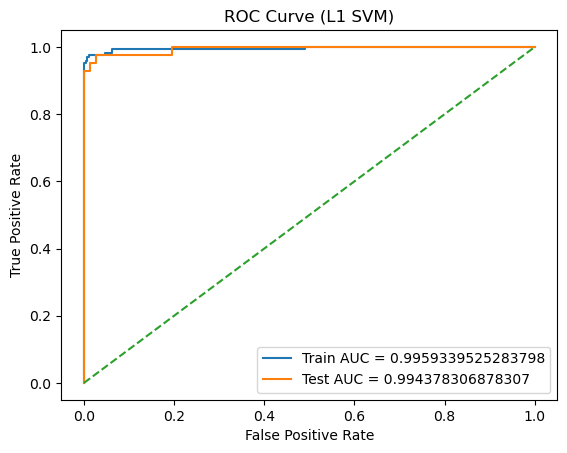

In [8]:
params = {"C": np.logspace(-3, 3, 10)}
l = []
saved_data = {}

for i in range(30):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=i)
    results, model = l1_svm_model(X_train, y_train, X_test, y_test, params)
    l.append(results)

    if i==10:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        saved_data["y_train"] = y_train
        saved_data["y_test"] = y_test
        saved_data["y_train_pred"] = model.predict(X_train_scaled)
        saved_data["y_test_pred"] = model.predict(X_test_scaled)
        saved_data["y_train_scores"] = model.decision_function(X_train_scaled)
        saved_data["y_test_scores"] = model.decision_function(X_test_scaled)


df_results = pd.DataFrame(l)
display(df_results)
print("Average Score Results for supervised:\n")
print(df_results.mean())

cm_train = confusion_matrix(saved_data["y_train"], saved_data["y_train_pred"])
cm_test = confusion_matrix(saved_data["y_test"], saved_data["y_test_pred"])

print("Train Confusion Matrix:\n", cm_train)
print("Test Confusion Matrix:\n", cm_test)

fpr_train, tpr_train, _ = roc_curve(saved_data["y_train"], saved_data["y_train_scores"])
auc_train = auc(fpr_train, tpr_train)
fpr_test, tpr_test, _ = roc_curve(saved_data["y_test"], saved_data["y_test_scores"])
auc_test = auc(fpr_test, tpr_test)

plt.figure()
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (L1 SVM)")
plt.legend()
plt.show()

#### (ii) Semi-Supervised Learning/ Self-training

##### (A)

In [9]:
def split_data_semi(X_train, y_train):
    X_labeled = []
    y_labeled = []
    X_unlabeled = []

    neg = np.where(y_train == 0)[0]
    pos = np.where(y_train == 1)[0]
    np.random.shuffle(neg)
    np.random.shuffle(pos)

    half_neg = len(neg) // 2
    half_pos = len(pos) // 2

    labeled_data = np.concatenate([neg[:half_neg], pos[:half_pos]])
    np.random.shuffle(labeled_data)
    unlabeled_data = np.concatenate([neg[half_neg:], pos[half_pos:]])
    np.random.shuffle(unlabeled_data)

    X_labeled = X_train[labeled_data]
    y_labeled = y_train[labeled_data]
    X_unlabeled = X_train[unlabeled_data]

    return X_labeled, y_labeled, X_unlabeled

##### (B)

In [10]:
def semi_supervised_svm(x_train, y_train, x_test, y_test, params):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(x_train)
    X_test_scaled = scaler.transform(x_test)
    X_l, y_l, X_u = split_data_semi(X_train_scaled, y_train.values)

    grid_search = GridSearchCV(
        estimator=LinearSVC(penalty='l1', dual=False, max_iter=2000),
        param_grid=params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    grid_search.fit(X_l, y_l)
    best_C = grid_search.best_params_['C']

    while len(X_u) > 0:
        model = LinearSVC(penalty='l1', dual=False, C=best_C, max_iter=2000)
        model.fit(X_l, y_l)

        distances = model.decision_function(X_u)
        idx = np.argmax(np.abs(distances))

        pseudo_label = model.predict(X_u[idx].reshape(1, -1))[0]
        X_l = np.vstack([X_l, X_u[idx]])
        y_l = np.append(y_l, pseudo_label)
        X_u = np.delete(X_u, idx, axis=0)

    final_model = model

    y_train_pred = final_model.predict(X_train_scaled)
    y_test_pred = final_model.predict(X_test_scaled)
    y_train_scores = final_model.decision_function(X_train_scaled)
    y_test_scores = final_model.decision_function(X_test_scaled)

    result = {
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_precision": precision_score(y_train, y_train_pred),
        "train_recall": recall_score(y_train, y_train_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "train_auc": roc_auc_score(y_train, y_train_scores),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_precision": precision_score(y_test, y_test_pred),
        "test_recall": recall_score(y_test, y_test_pred),
        "test_f1": f1_score(y_test, y_test_pred),
        "test_auc": roc_auc_score(y_test, y_test_scores)
    }
    return result, final_model

,train_accuracy,train_precision,train_recall,train_f1,train_auc,test_accuracy,test_precision,test_recall,test_f1,test_auc
0,0.978022,0.976190,0.964706,0.970414,0.995315,0.929825,0.886364,0.928571,0.906977,0.991071
1,0.975824,0.981818,0.952941,0.967164,0.995294,0.973684,1.000000,0.928571,0.962963,0.997024
2,0.975824,0.970414,0.964706,0.967552,0.996883,0.973684,0.975610,0.952381,0.963855,0.987434
3,0.975824,0.987730,0.947059,0.966967,0.995005,0.982456,1.000000,0.952381,0.975610,0.999339
4,0.984615,0.976608,0.982353,0.979472,0.991455,0.921053,0.945946,0.833333,0.886076,0.978175
5,0.975824,0.993789,0.941176,0.966767,0.995377,0.964912,1.000000,0.904762,0.950000,0.997354
6,0.978022,0.976190,0.964706,0.970414,0.997482,0.956140,0.930233,0.952381,0.941176,0.974206
7,0.964835,0.987342,0.917647,0.951220,0.990815,0.964912,1.000000,0.904762,0.950000,0.994709
8,0.982418,0.987952,0.964706,0.976190,0.996037,0.964912,1.000000,0.904762,0.950000,0.995701
9,0.978022,0.987805,0.952941,0.970060,0.995521,0.947368,1.000000,0.857143,0.923077,0.997354


Average Score Results for supervised:

train_accuracy     0.975385
train_precision    0.979839
train_recall       0.953922
train_f1           0.966545
train_auc          0.994314
test_accuracy      0.956725
test_precision     0.955012
test_recall        0.928571
test_f1            0.940610
test_auc           0.990179
dtype: float64
Train Confusion Matrix:
 [[281   4]
 [  6 164]]
Test Confusion Matrix:
 [[67  5]
 [ 3 39]]


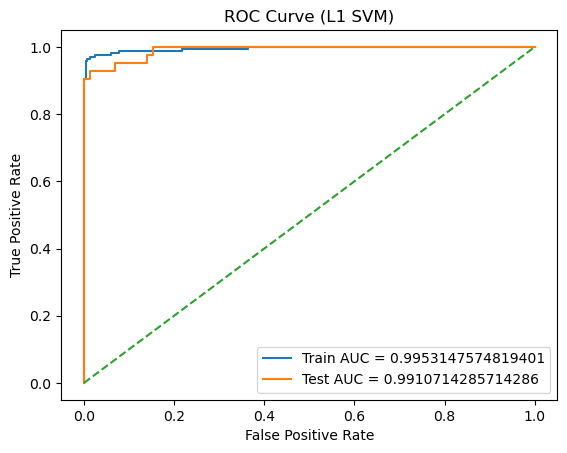

In [11]:
params = {"C": np.logspace(-3, 3, 10)}
l1 = []
saved_data1 = {}

for i in range(30):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=i
    )

    results, model = semi_supervised_svm(X_train, y_train, X_test, y_test, params)
    l1.append(results)

    if i == 0:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        saved_data1["y_train"] = y_train
        saved_data1["y_test"] = y_test
        saved_data1["y_train_pred"] = model.predict(X_train_scaled)
        saved_data1["y_test_pred"] = model.predict(X_test_scaled)
        saved_data1["y_train_scores"] = model.decision_function(X_train_scaled)
        saved_data1["y_test_scores"] = model.decision_function(X_test_scaled)


df_results1 = pd.DataFrame(l1)
display(df_results1)
print("Average Score Results for supervised:\n")
print(df_results1.mean())

cm_train = confusion_matrix(saved_data1["y_train"], saved_data1["y_train_pred"])
cm_test = confusion_matrix(saved_data1["y_test"], saved_data1["y_test_pred"])

print("Train Confusion Matrix:\n", cm_train)
print("Test Confusion Matrix:\n", cm_test)

fpr_train, tpr_train, _ = roc_curve(saved_data1["y_train"], saved_data1["y_train_scores"])
auc_train = auc(fpr_train, tpr_train)
fpr_test, tpr_test, _ = roc_curve(saved_data1["y_test"], saved_data1["y_test_scores"])
auc_test = auc(fpr_test, tpr_test)

plt.figure()
plt.plot(fpr_train, tpr_train, label=f"Train AUC = {auc_train}")
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {auc_test}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (L1 SVM)")
plt.legend()
plt.show()

#### (iii) Unsupervised Learning

##### (A)

In [12]:
def kmeans_unsupervised(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    y_train = y_train.values if hasattr(y_train, "values") else y_train
    y_test = y_test.values if hasattr(y_test, "values") else y_test

    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
    clusters = kmeans.fit_predict(X_train_scaled)
    centers = kmeans.cluster_centers_

    cluster_label_map = {}
    for k in [0, 1]:
        idx = np.where(clusters == k)[0]
        dist = np.linalg.norm(X_train_scaled[idx] - centers[k], axis=1)
        closest_30 = idx[np.argsort(dist)[:30]]
        cluster_label_map[k] = mode(y_train[closest_30], keepdims=True).mode[0]

    train_pred = np.array([cluster_label_map[c] for c in clusters])

    positive_cluster = [k for k, v in cluster_label_map.items() if v == 1][0]
    train_scores = -np.linalg.norm(X_train_scaled - centers[positive_cluster], axis=1)

    test_clusters = kmeans.predict(X_test_scaled)
    test_pred = np.array([cluster_label_map[c] for c in test_clusters])
    test_scores = -np.linalg.norm(X_test_scaled - centers[positive_cluster], axis=1)

    train_metrics = {
        "accuracy": accuracy_score(y_train, train_pred),
        "precision": precision_score(y_train, train_pred),
        "recall": recall_score(y_train, train_pred),
        "f1": f1_score(y_train, train_pred),
        "auc": roc_auc_score(y_train, train_scores)
    }
    test_metrics = {
        "accuracy": accuracy_score(y_test, test_pred),
        "precision": precision_score(y_test, test_pred),
        "recall": recall_score(y_test, test_pred),
        "f1": f1_score(y_test, test_pred),
        "auc": roc_auc_score(y_test, test_scores)
    }

    return train_metrics, test_metrics, kmeans, scaler, cluster_label_map, centers


(B) and (C)

Train Avg:
 accuracy     0.910110
precision    0.923834
recall       0.828039
f1           0.873124
auc          0.882336
dtype: float64
Test Avg:
 accuracy     0.905263
precision    0.909638
recall       0.826190
f1           0.864657
auc          0.872321
dtype: float64
Train CM:
 [[275  10]
 [ 30 140]]
Test CM:
 [[69  3]
 [ 7 35]]


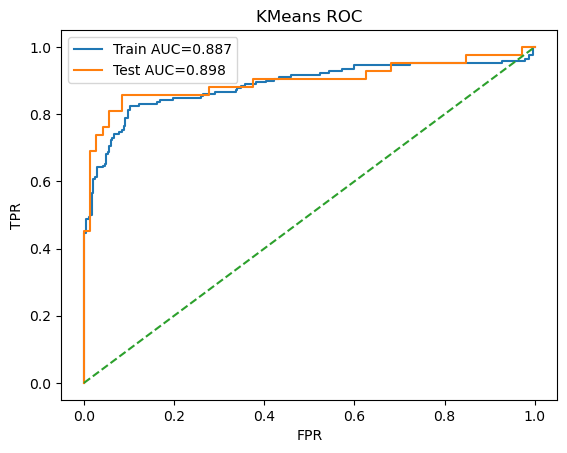

In [13]:
train_results, test_results = [], []
saved_km = {}

for i in range(30):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=i)
    tr, te, kmeans, scaler, label_map, centers = kmeans_unsupervised(X_train, y_train, X_test, y_test)
    train_results.append(tr)
    test_results.append(te)

    if i == 10:
        saved_km = {
            "kmeans": kmeans, "scaler": scaler,
            "label_map": label_map, "centers": centers,
            "X_train": X_train, "y_train": y_train,
            "X_test": X_test, "y_test": y_test
        }

print("Train Avg:\n", pd.DataFrame(train_results).mean())
print("Test Avg:\n", pd.DataFrame(test_results).mean())

km = saved_km["kmeans"]
sc = saved_km["scaler"]
lmap = saved_km["label_map"]
ctrs = saved_km["centers"]

X_tr_sc = sc.transform(saved_km["X_train"])
X_te_sc = sc.transform(saved_km["X_test"])
y_tr = saved_km["y_train"].values
y_te = saved_km["y_test"].values

pos_cluster = [k for k, v in lmap.items() if v == 1][0]

tr_clusters = km.labels_
tr_pred = np.array([lmap[c] for c in tr_clusters])
tr_scores = -np.linalg.norm(X_tr_sc - ctrs[pos_cluster], axis=1)

te_clusters = km.predict(X_te_sc)
te_pred = np.array([lmap[c] for c in te_clusters])
te_scores = -np.linalg.norm(X_te_sc - ctrs[pos_cluster], axis=1)

print("Train CM:\n", confusion_matrix(y_tr, tr_pred))
print("Test CM:\n", confusion_matrix(y_te, te_pred))

fpr_tr, tpr_tr, _ = roc_curve(y_tr, tr_scores)
fpr_te, tpr_te, _ = roc_curve(y_te, te_scores)

plt.figure()
plt.plot(fpr_tr, tpr_tr, label=f"Train AUC={auc(fpr_tr, tpr_tr):.3f}")
plt.plot(fpr_te, tpr_te, label=f"Test AUC={auc(fpr_te, tpr_te):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("KMeans ROC")
plt.legend()
plt.show()

#### (iv) Spectral Clustering

In [ ]:
def kmeans_unsupervised(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    y_train = y_train.values if hasattr(y_train, "values") else y_train
    y_test = y_test.values if hasattr(y_test, "values") else y_test

    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
    train_clusters = kmeans.fit_predict(X_train_scaled)
    centers = kmeans.cluster_centers_
    cluster_label_map = {}

    for c in [0, 1]:
        idx = np.where(train_clusters == c)[0]

        distances = np.linalg.norm(X_train_scaled[idx] - centers[c], axis=1)
        closest = idx[np.argsort(distances)[:min(30, len(idx))]]

        majority_label = int(np.round(np.mean(y_train[closest])))
        cluster_label_map[c] = majority_label

    train_pred = np.array([cluster_label_map[c] for c in train_clusters])
    test_clusters = kmeans.predict(X_test_scaled)
    test_pred = np.array([cluster_label_map[c] for c in test_clusters])
    train_scores = (
        np.linalg.norm(X_train_scaled - centers[1], axis=1)
        - np.linalg.norm(X_train_scaled - centers[0], axis=1)
    )

    test_scores = (
        np.linalg.norm(X_test_scaled - centers[1], axis=1)
        - np.linalg.norm(X_test_scaled - centers[0], axis=1)
    )

    result = {
        "train_accuracy": accuracy_score(y_train, train_pred),
        "train_precision": precision_score(y_train, train_pred),
        "train_recall": recall_score(y_train, train_pred),
        "train_f1": f1_score(y_train, train_pred),
        "train_auc": roc_auc_score(y_train, train_scores),

        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision": precision_score(y_test, test_pred),
        "test_recall": recall_score(y_test, test_pred),
        "test_f1": f1_score(y_test, test_pred),
        "test_auc": roc_auc_score(y_test, test_scores)
    }

    return result, kmeans, scaler, cluster_label_map, centers

In [15]:
kmeans_results = []
saved_km = {}

for i in range(30):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=i
    )

    result, model, scaler, label_map, centers = kmeans_unsupervised(
        X_train, y_train, X_test, y_test
    )

    kmeans_results.append(result)

    if i == 10:
        saved_km = {
            "model": model,
            "scaler": scaler,
            "label_map": label_map,
            "centers": centers,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test
        }

df_km = pd.DataFrame(kmeans_results)
print("KMeans Average Results:\n")
print(df_km.mean())

KMeans Average Results:

train_accuracy     0.910110
train_precision    0.923834
train_recall       0.828039
train_f1           0.873124
train_auc          0.405596
test_accuracy      0.905263
test_precision     0.909638
test_recall        0.826190
test_f1            0.864657
test_auc           0.403263
dtype: float64


Train Confusion Matrix:
 [[275  10]
 [ 30 140]]
Test Confusion Matrix:
 [[69  3]
 [ 7 35]]


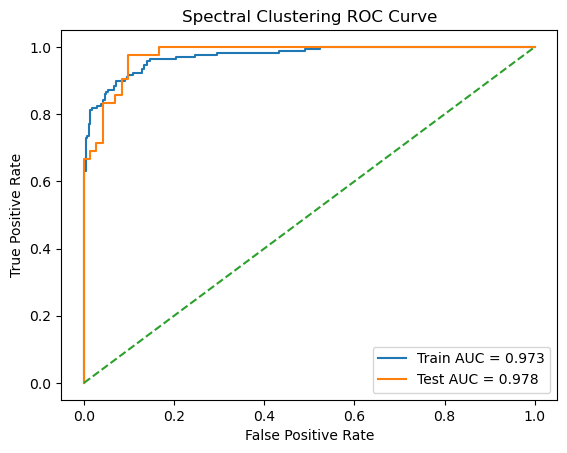

In [16]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

model = saved_km["model"]
scaler = saved_km["scaler"]
label_map = saved_km["label_map"]
centers = saved_km["centers"]

X_train = saved_km["X_train"]
X_test = saved_km["X_test"]
y_train = saved_km["y_train"].values if hasattr(saved_km["y_train"], "values") else saved_km["y_train"]
y_test = saved_km["y_test"].values if hasattr(saved_km["y_test"], "values") else saved_km["y_test"]

X_tr_sc = scaler.transform(X_train)
X_te_sc = scaler.transform(X_test)

tr_clusters = model.predict(X_tr_sc)
te_clusters = model.predict(X_te_sc)
tr_pred = np.array([label_map[c] for c in tr_clusters])
te_pred = np.array([label_map[c] for c in te_clusters])

tr_scores = (
    np.linalg.norm(X_tr_sc - centers[1], axis=1)
    - np.linalg.norm(X_tr_sc - centers[0], axis=1)
)

te_scores = (
    np.linalg.norm(X_te_sc - centers[1], axis=1)
    - np.linalg.norm(X_te_sc - centers[0], axis=1)
)

print("Train Confusion Matrix:\n", confusion_matrix(y_train, tr_pred))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, te_pred))

fpr_tr, tpr_tr, _ = roc_curve(y_train, tr_scores)
fpr_te, tpr_te, _ = roc_curve(y_test, te_scores)

plt.figure()
plt.plot(fpr_tr, tpr_tr, label=f"Train AUC = {auc(fpr_tr, tpr_tr):.3f}")
plt.plot(fpr_te, tpr_te, label=f"Test AUC = {auc(fpr_te, tpr_te):.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Spectral Clustering ROC Curve")
plt.legend()
plt.show()

#### (iv) Compare

Supervised learning gave the best results followed by semi-supervised, spectral clustering and then unsupervised learning for this task.

## 2. Active Learning Using Support Vector Machines

### (a) Download the banknote authentication Data Set

In [17]:
df1 = pd.read_csv("../data/data_banknote_authentication.txt", header=None)

X = df1.iloc[:, :-1]
y = df1.iloc[:, -1]
print("Dataset shape:", X.shape)
print("Class distribution:", np.bincount(y))
df1.head()

Dataset shape: (1372, 4)
Class distribution: [762 610]


,0,1,2,3,4
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [18]:
X_all = df1.iloc[:, :-1].values
y_all = df1.iloc[:, -1].values

In [19]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=472, random_state=42)
train_idx, test_idx = next(sss.split(X_all, y_all))

X_train = X_all[train_idx]
X_test  = X_all[test_idx]
y_train = y_all[train_idx]
y_test  = y_all[test_idx]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 900
Test size: 472


### (b) Repeat each of the following two procedures 50 times

#### (i) Passive

In [20]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc  = scaler.transform(X_test)

C_grid = np.logspace(-3, 3, 7)

grid = GridSearchCV(
    LinearSVC(penalty='l1', dual=False, max_iter=1000),
    param_grid={"C": C_grid},
    cv=5, scoring='accuracy', n_jobs=-1
)
grid.fit(X_train_sc, y_train)
best_C = grid.best_params_["C"]
print(f"Best C: {best_C}")

Best C: 10.0


In [21]:
def train_svm(X_pool_sc, y_pool, best_C):
    if len(np.unique(y_pool)) < 2:
        return None
    model = LinearSVC(penalty='l1', dual=False, C=best_C, max_iter=1000)
    model.fit(X_pool_sc, y_pool)
    return model

In [22]:
def passive_learning_run(X_train_sc, y_train, X_test_sc, y_test, best_C, seed):
    rng = np.random.RandomState(seed)
    remaining_idx = np.arange(len(X_train_sc))
    rng.shuffle(remaining_idx)
    pool_idx      = list(remaining_idx[:10])
    remaining_idx = list(remaining_idx[10:])

    attempts = 0
    while len(np.unique(y_train[pool_idx])) < 2 and attempts < 100:
        rng.shuffle(remaining_idx)
        pool_idx      = list(remaining_idx[:10])
        remaining_idx = list(remaining_idx[10:])
        attempts += 1

    errors = []
    for step in range(90):
        model = train_svm(X_train_sc[pool_idx], y_train[pool_idx], best_C)
        if model is None:
            errors.append(errors[-1] if errors else 1.0)
        else:
            pred = model.predict(X_test_sc)
            errors.append(1 - accuracy_score(y_test, pred))

        n_add = min(10, len(remaining_idx))
        if n_add == 0:
            errors.extend([errors[-1]] * (89 - step))
            break

        pool_idx += remaining_idx[:n_add]
        remaining_idx = remaining_idx[n_add:]

    return errors


#### (ii) Active

In [23]:
def active_learning_run(X_train_sc, y_train, X_test_sc, y_test, best_C, seed):
    rng = np.random.RandomState(seed)
    remaining_idx = np.arange(len(X_train_sc))
    rng.shuffle(remaining_idx)

    pool_idx = list(remaining_idx[:10])
    remaining_idx = list(remaining_idx[10:])

    attempts = 0
    while len(np.unique(y_train[pool_idx])) < 2 and attempts < 100:
        rng.shuffle(remaining_idx)
        pool_idx = list(remaining_idx[:10])
        remaining_idx = list(remaining_idx[10:])
        attempts += 1

    errors = []

    for step in range(90):
        model = train_svm(X_train_sc[pool_idx], y_train[pool_idx], best_C)

        if model is None:
            errors.append(errors[-1] if errors else 1.0)
            n_add = min(10, len(remaining_idx))
            pool_idx += remaining_idx[:n_add]
            remaining_idx = remaining_idx[n_add:]
            continue

        pred = model.predict(X_test_sc)
        errors.append(1 - accuracy_score(y_test, pred))

        n_add = min(10, len(remaining_idx))
        if n_add == 0:
            errors.extend([errors[-1]] * (89 - step))
            break

        rem_arr = np.array(remaining_idx)
        distances = np.abs(model.decision_function(X_train_sc[rem_arr]))
        closest = np.argsort(distances)[:n_add]

        pool_idx += rem_arr[closest].tolist()
        remaining_idx = rem_arr[[i for i in range(len(rem_arr)) if i not in set(closest)]].tolist()

    return errors

### (c) Average the 50 test errors

In [24]:
passive_all = []
active_all  = []

for run in range(50):
    print(f"Run {run}/50")

    passive_all.append(passive_learning_run(X_train_sc, y_train, X_test_sc, y_test, best_C, seed=run))
    active_all.append(active_learning_run(X_train_sc, y_train, X_test_sc, y_test, best_C, seed=run))

passive_errors = np.array(passive_all)
active_errors  = np.array(active_all) 
print("Done!")

Run 0/50
Run 1/50
Run 2/50
Run 3/50
Run 4/50
Run 5/50
Run 6/50
Run 7/50
Run 8/50
Run 9/50
Run 10/50
Run 11/50
Run 12/50
Run 13/50
Run 14/50
Run 15/50
Run 16/50
Run 17/50
Run 18/50
Run 19/50
Run 20/50
Run 21/50
Run 22/50
Run 23/50
Run 24/50
Run 25/50
Run 26/50
Run 27/50
Run 28/50
Run 29/50
Run 30/50
Run 31/50
Run 32/50
Run 33/50
Run 34/50
Run 35/50
Run 36/50
Run 37/50
Run 38/50
Run 39/50
Run 40/50
Run 41/50
Run 42/50
Run 43/50
Run 44/50
Run 45/50
Run 46/50
Run 47/50
Run 48/50
Run 49/50
Done!


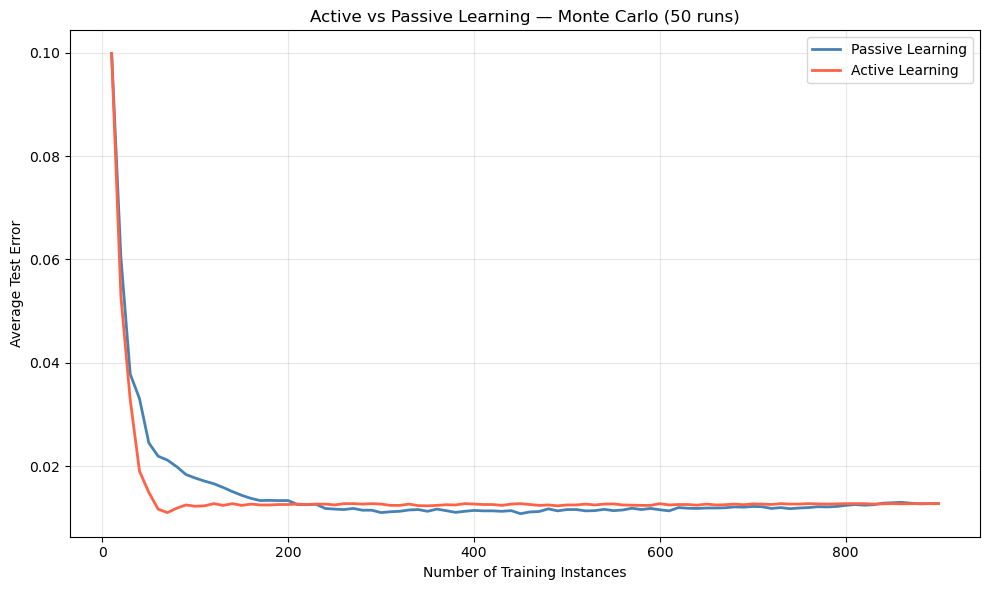

Passive error at 100 pts : 0.0177
Active error at 100 pts : 0.0122
Passive error at 900 pts : 0.0127
Active error at 900 pts : 0.0127


In [25]:
n_points = np.arange(10, 901, 10)
avg_passive = passive_errors.mean(axis=0)
avg_active = active_errors.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.plot(n_points, avg_passive, label="Passive Learning", color="steelblue", linewidth=2)
plt.plot(n_points, avg_active,  label="Active Learning",  color="tomato",    linewidth=2)
plt.xlabel("Number of Training Instances")
plt.ylabel("Average Test Error")
plt.title("Active vs Passive Learning — Monte Carlo (50 runs)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Passive error at 100 pts : {avg_passive[9]:.4f}")
print(f"Active error at 100 pts : {avg_active[9]:.4f}")
print(f"Passive error at 900 pts : {avg_passive[-1]:.4f}")
print(f"Active error at 900 pts : {avg_active[-1]:.4f}")

Active learning drops faster than passive learning in the earlier training instances and reaches low error in lesser number of runs, but they later converge approximately.

### REFERENCES

https://stackoverflow.com/questions/51345244/unbalanced-dataset-split#:~:text=Comments&text=I%20would%20suggest%20that%20you,dividing%20dataset%20into%20two%20parts.

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html

https://github.com/sayali-nakashe/Active-passive-SVM/blob/master/Active%20Learning%20and%20Passive%20Learning%20using%20Support%20Vector%20Machines.ipynb



### AI PROMPTS

Is stratify a good way to split an imbalanced dataset

Monte carlo simulation

Fix and optimize code, make code resusable

How to implement supervised, semi-supervised, unsupervised and spectral clustering using svms?

What is passive learning and active learning and how to implement with SVMs? How to speed up the run?